# 20 Newsgroups Text Classification using Naive Bayes

## Objective
The goal of this project is to classify news articles into different categories using Natural Language Processing (NLP) techniques and a Naive Bayes classifier.

We will use:
- TF-IDF for text vectorization
- Multinomial Naive Bayes for classification
- Evaluation metrics like accuracy, precision, and recall
- Confusion matrix for performance analysis

## Importing Required Libraries

We import essential libraries for data processing, visualization, and machine learning.

In [1]:
#import required libraries
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

## Dataset Selection and Loading

In this section, we select two categories from the 20 Newsgroups dataset and load the corresponding news articles.

The selected categories are:
- **sci.space** (Space Science)
- **rec.sport.hockey** (Hockey Sports)

To improve text quality, headers, footers, and quoted text are removed from the documents.

### Why it is important:
- Reduces the complexity of the classification task
- Makes it easier to visualize and understand the results
- Removes unnecessary information that may not contribute to classification

### Interpretation:
- **X** contains the news article text
- **y** contains the corresponding category labels
- The target names show the categories represented by the labels

### In this project:
We load a subset of the 20 Newsgroups dataset containing only two categories and display basic information such as the total number of documents and category names.

In [3]:
# Select only two categories
categories = [
    'sci.space',
    'rec.sport.hockey'
]

# Load dataset
dataset = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes')
)

# Store text data and labels
X = dataset.data
y = dataset.target

# Print basic information
print("Total documents:", len(X))
print("Target names:", dataset.target_names)

Total documents: 1193
Target names: ['rec.sport.hockey', 'sci.space']


## Data Preparation using Pandas

We convert the dataset into a pandas DataFrame for better handling and analysis.

In [4]:
# Create dataframe
df = pd.DataFrame({
    'text': X,
    'target': y
})

# Convert target numbers into category names
df['category'] = df['target'].map({
    0: dataset.target_names[0],
    1: dataset.target_names[1]
})

# Show first 5 rows
df.head()

,text,target,category
0,Individual leaders by total points (Final stan...,0,rec.sport.hockey
1,\n\nWhy not? I believe both the Devils and Isl...,0,rec.sport.hockey
2,Reply address: mark.prado@permanet.org\n\nIf a...,1,sci.space
3,Which GERMAN satellite channels will show the ...,0,rec.sport.hockey
4,"We are not at the end of the Space Age, but on...",1,sci.space


## Exploratory Data Analysis (EDA)

We analyze class distribution to understand how data is distributed across categories.

In [5]:
# Check dataset size
print("Dataset shape:", df.shape)

# Check class balance
print("\nClass distribution:\n")
print(df["category"].value_counts())

Dataset shape: (1193, 3)

Class distribution:

category
rec.sport.hockey    600
sci.space           593
Name: count, dtype: int64


## Category Distribution

In this section, we analyze the number of documents available in each news category.

A bar chart is used to visualize the distribution of articles across categories in the dataset.

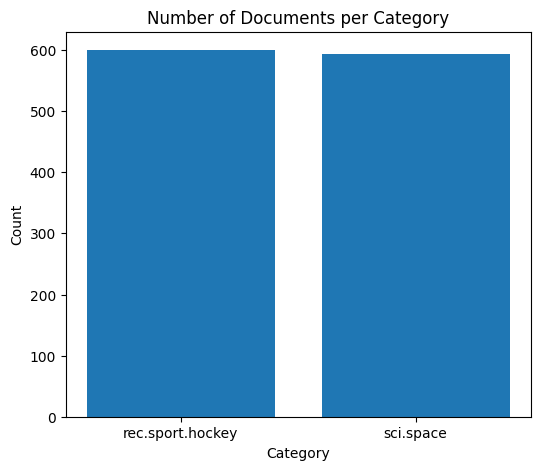

In [16]:
# Count documents in each category
category_counts = df['category'].value_counts()

# Plot bar chart
plt.figure(figsize=(6, 5))

plt.bar(category_counts.index, category_counts.values)

# Add title and labels
plt.title("Number of Documents per Category")
plt.xlabel("Category")
plt.ylabel("Count")

# Show plot
plt.show()

## Text Length Analysis
In this section, we calculate the length of each news article by counting the number of characters in the text.

A new column called **text_length** is added to the DataFrame to store the length of each article.


In [28]:
# Create a new column for text length
df['text_length'] = df['text'].apply(len)

# Show first few lengths
print(df[['category', 'text_length']].head())

           category  text_length
0  rec.sport.hockey        38422
1  rec.sport.hockey          297
2         sci.space         1338
3  rec.sport.hockey          175
4         sci.space          491


## Train-Test Split

We split the dataset into training and testing sets to evaluate model performance fairly.

In [17]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['target'],
    test_size=0.2,
    random_state=42
)

# Print sizes
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 954
Testing samples: 239


## Text Preprocessing using TF-IDF

We convert text data into numerical features using TF-IDF (Term Frequency - Inverse Document Frequency).
This helps machine learning models understand text data.

In [18]:
# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(stop_words='english')

# Fit and transform training data
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform testing data
X_test_tfidf = vectorizer.transform(X_test)

# Print shape of transformed data
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (954, 16657)
Testing TF-IDF shape: (239, 16657)


## Model Training - Naive Bayes

We use Multinomial Naive Bayes, which is a strong baseline model for text classification problems.

In [19]:
# Create model
model = MultinomialNB()

# Train model
model.fit(X_train_tfidf, y_train)

print("Model training completed")

Model training completed


## Predictions

The trained model is used to predict categories for unseen test data.

In [20]:
# Predict categories for test data
predictions = model.predict(X_test_tfidf)

# Show first 10 predictions
print("Predictions:\n", predictions[:10])

Predictions:
 [1 1 0 0 1 0 1 1 1 1]


## Model Evaluation

We evaluate the model using:
- Accuracy
- Precision
- Recall

These metrics help us understand how well the model performs.

In [21]:
# Calculate metrics
accuracy = accuracy_score(y_test, predictions)

precision = precision_score(y_test, predictions)

recall = recall_score(y_test, predictions)

# Print results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.9790794979079498
Precision: 0.957983193277311
Recall: 1.0


## Confusion Matrix

A confusion matrix is used to visualize correct and incorrect predictions for each class.

[[120   5]
 [  0 114]]


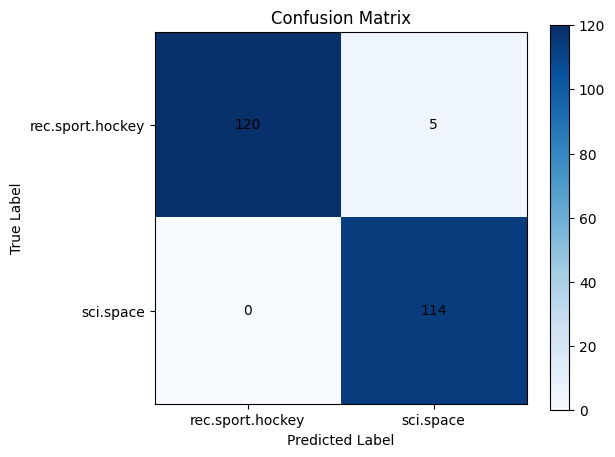

In [27]:
# Create confusion matrix
cm = confusion_matrix(y_test, predictions)

print(cm)

# Plot confusion matrix
plt.figure(figsize=(6, 5))

plt.imshow(cm, cmap='Blues')

# Add title and labels
plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add tick labels
plt.xticks([0, 1], dataset.target_names)
plt.yticks([0, 1], dataset.target_names)

# Add numbers inside matrix
for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j], ha='center', va='center')

# Add color bar
plt.colorbar()

# Show plot
plt.show()

## Actual vs Predicted Values
We plot the first 50 test samples to compare actual and predicted categories visually.

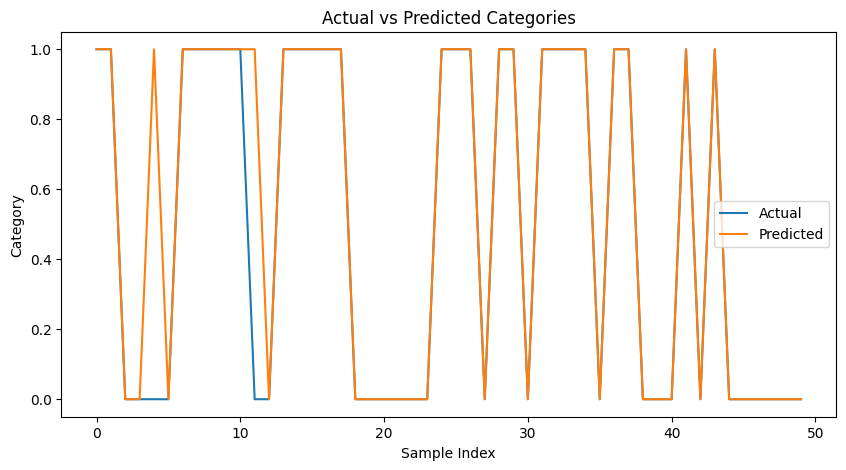

In [29]:
# Plot actual vs predicted values
plt.figure(figsize=(10, 5))

plt.plot(y_test.values[:50], label="Actual")
plt.plot(predictions[:50], label="Predicted")

# Add title and labels
plt.title("Actual vs Predicted Categories")
plt.xlabel("Sample Index")
plt.ylabel("Category")

# Add legend
plt.legend()

# Show plot
plt.show()

## Results Summary

The Naive Bayes model performs well for text classification tasks due to its probabilistic nature.

Key observations:
- Good accuracy on test data
- Works well with TF-IDF features
- Fast and efficient for large datasets

## Reflection on AI-Assisted Coding

In this project, AI tools were used to:
- Generate initial code structure
- Debug errors in sklearn implementation
- Explain TF-IDF and Naive Bayes concepts
- Improve visualization and evaluation code

Prompt engineering helped improve output quality by:
- Providing structured instructions
- Iteratively refining prompts
- Asking for optimized and commented code

## Conclusion

This project demonstrates how machine learning can be applied to text classification using NLP techniques.

We successfully:
- Processed text data using TF-IDF
- Trained a Naive Bayes classifier
- Evaluated model performance using multiple metrics
- Visualized results using confusion matrix

This shows the power of simple probabilistic models for NLP tasks.